In [2]:
import os
import glob

# Correct path
data_folder = r'C:\Users\andov\VT Bootcamp\capstone_data'

files = sorted(glob.glob(os.path.join(data_folder, '*.csv')) + 
               glob.glob(os.path.join(data_folder, '*.xlsx')))

print(f"Total files: {len(files)}\n")
for f in files:
    print(f"  - {os.path.basename(f)}")

Total files: 11

  - 12in54cmcsv.csv
  - 13in54cmcsv.xlsx
  - 14in54cmcsv.csv
  - 15in54cmcsv.csv
  - 16in54cmcsv.csv
  - 17in54cmcsv.csv
  - 18in55cmagi.csv
  - 19in55cmcsv.csv
  - 20in55cmcsv.csv
  - 21in55cmcsv.csv
  - IRS SOI Historic Table 2.csv


In [3]:
import pandas as pd

# Test load: 2021 file
test_file = r'C:\Users\andov\VT Bootcamp\capstone_data\21in55cmcsv.csv'

df_test = pd.read_csv(test_file, thousands=',', low_memory=False)

print(f"Rows: {df_test.shape[0]}")
print(f"Columns: {df_test.shape[1]}")
print(f"\nFirst 3 columns: {df_test.columns[:3].tolist()}")
print(f"\nFirst 5 rows of STATE and AGI_STUB:")
df_test[['STATE', 'AGI_STUB']].head()

Rows: 594
Columns: 165

First 3 columns: ['STATE', 'AGI_STUB', 'N1']

First 5 rows of STATE and AGI_STUB:


,STATE,AGI_STUB
0,US,0
1,US,1
2,US,2
3,US,3
4,US,4


In [5]:
# Merge All 11 Years: 2012-2022

import pandas as pd
import os

data_folder = r'C:\Users\andov\VT Bootcamp\capstone_data'

# Map year to filename
year_files = {
    2012: '12in54cmcsv.csv',
    2013: '13in54cmcsv.xlsx',
    2014: '14in54cmcsv.csv',
    2015: '15in54cmcsv.csv',
    2016: '16in54cmcsv.csv',
    2017: '17in54cmcsv.csv',
    2018: '18in55cmagi.csv',
    2019: '19in55cmcsv.csv',
    2020: '20in55cmcsv.csv',
    2021: '21in55cmcsv.csv',
    2022: 'IRS SOI Historic Table 2.csv',
}

all_data = []

for year, filename in year_files.items():
    filepath = os.path.join(data_folder, filename)
    
    try:
        if filename.endswith('.xlsx'):
            df = pd.read_excel(filepath)
        else:
            df = pd.read_csv(filepath, thousands=',', low_memory=False)
        
        df['YEAR'] = year
        all_data.append(df)
        print(f"✅ {year}: {df.shape[0]:>4} rows × {df.shape[1]:>4} cols")
    
    except Exception as e:
        print(f"❌ {year}: ERROR - {e}")

# Combine all
df_combined = pd.concat(all_data, ignore_index=True, sort=False)

print(f"\n{'='*40}")
print(f"TOTAL: {df_combined.shape[0]} rows × {df_combined.shape[1]} cols")
print(f"{'='*40}")

✅ 2012:  583 rows ×  108 cols
✅ 2013:  585 rows ×  112 cols
✅ 2014:  583 rows ×  126 cols
✅ 2015:  583 rows ×  130 cols
✅ 2016:  583 rows ×  146 cols
✅ 2017:  583 rows ×  152 cols
✅ 2018:  594 rows ×  152 cols
✅ 2019:  594 rows ×  151 cols
✅ 2020:  594 rows ×  164 cols
✅ 2021:  594 rows ×  166 cols
✅ 2022:  594 rows ×  164 cols

TOTAL: 6470 rows × 309 cols


In [7]:
#  Verify the Merge

# Year breakdown
print("📅 Rows per year:")
print(df_combined['YEAR'].value_counts().sort_index())

print(f"\n📊 Total: {len(df_combined)} rows")

# Check key columns exist
key_cols = ['STATE', 'AGI_STUB', 'A00100', 'A06500', 'YEAR']
print(f"\n🔑 Key columns check:")
for col in key_cols:
    if col in df_combined.columns:
        nulls = df_combined[col].isna().sum()
        print(f"  ✅ {col}: {nulls} nulls")
    else:
        print(f"  ❌ {col}: NOT FOUND")

# Sample rows
print(f"\n📋 Sample (US total, all years):")
us_total = df_combined[(df_combined['STATE'] == 'US') & (df_combined['AGI_STUB'] == 0)]
us_total[['YEAR', 'STATE', 'AGI_STUB', 'A00100', 'A06500']]

📅 Rows per year:
YEAR
2012    583
2013    585
2014    583
2015    583
2016    583
2017    583
2018    594
2019    594
2020    594
2021    594
2022    594
Name: count, dtype: int64

📊 Total: 6470 rows

🔑 Key columns check:
  ✅ STATE: 1168 nulls
  ✅ AGI_STUB: 1168 nulls
  ✅ A00100: 585 nulls
  ✅ A06500: 585 nulls
  ✅ YEAR: 0 nulls

📋 Sample (US total, all years):


,YEAR,STATE,AGI_STUB,A00100,A06500
1168,2014,US,0.0,9.706026e+09,1.362033e+09
1751,2015,US,0.0,1.014935e+10,1.444099e+09
2334,2016,US,0.0,1.020012e+10,1.439016e+09
2917,2017,US,0.0,1.099139e+10,1.589761e+09
3500,2018,US,0.0,1.162865e+10,1.518230e+09
4094,2019,US,0.0,1.194741e+10,1.559076e+09
4688,2020,US,0.0,1.255562e+10,1.694767e+09
5282,2021,US,0.0,1.477571e+10,2.224647e+09
5876,2022,US,0.0,1.478249e+10,2.105346e+09


In [9]:
# Diagnose the Issue
# Check 2012 column names
print("=" * 50)
print("2012 columns (first 15):")
df_2012 = df_combined[df_combined['YEAR'] == 2012]
print(df_2012.columns[:15].tolist())

print("\n" + "=" * 50)
print("2013 columns (first 15):")
df_2013 = df_combined[df_combined['YEAR'] == 2013]
print(df_2013.columns[:15].tolist())

print("\n" + "=" * 50)
print("Check 2012 sample row:")
df_2012.iloc[0:1, :8]

2012 columns (first 15):
['State', 'agi_stub', 'N1', 'MARS1', 'MARS2', 'MARS4', 'PREP', 'N2', 'NUMDEP', 'A00100', 'N02650', 'A02650', 'N00200', 'A00200', 'N00300']

2013 columns (first 15):
['State', 'agi_stub', 'N1', 'MARS1', 'MARS2', 'MARS4', 'PREP', 'N2', 'NUMDEP', 'A00100', 'N02650', 'A02650', 'N00200', 'A00200', 'N00300']

Check 2012 sample row:


,State,agi_stub,N1,MARS1,MARS2,MARS4,PREP,N2
0,US,0.0,145025450.0,66769990.0,53700420.0,21722220.0,80992600.0,287692220.0


In [11]:
# Fix Column Names
# Reset: re-merge with column name standardization
import pandas as pd
import os

data_folder = r'C:\Users\andov\VT Bootcamp\capstone_data'

year_files = {
    2012: '12in54cmcsv.csv',
    2013: '13in54cmcsv.xlsx',
    2014: '14in54cmcsv.csv',
    2015: '15in54cmcsv.csv',
    2016: '16in54cmcsv.csv',
    2017: '17in54cmcsv.csv',
    2018: '18in55cmagi.csv',
    2019: '19in55cmcsv.csv',
    2020: '20in55cmcsv.csv',
    2021: '21in55cmcsv.csv',
    2022: 'IRS SOI Historic Table 2.csv',
}

all_data = []

for year, filename in year_files.items():
    filepath = os.path.join(data_folder, filename)
    
    if filename.endswith('.xlsx'):
        df = pd.read_excel(filepath)
    else:
        df = pd.read_csv(filepath, thousands=',', low_memory=False)
    
    # 🔑 KEY FIX: Standardize all column names to UPPERCASE
    df.columns = df.columns.str.upper()
    
    df['YEAR'] = year
    all_data.append(df)
    print(f"✅ {year}: {df.shape[0]:>4} rows × {df.shape[1]:>4} cols")

# Combine
df_combined = pd.concat(all_data, ignore_index=True, sort=False)

print(f"\n{'='*40}")
print(f"TOTAL: {df_combined.shape[0]} rows × {df_combined.shape[1]} cols")
print(f"{'='*40}")

# Verify the fix
print(f"\nNull check:")
print(f"  STATE nulls: {df_combined['STATE'].isna().sum()}")
print(f"  AGI_STUB nulls: {df_combined['AGI_STUB'].isna().sum()}")
print(f"  A00100 nulls: {df_combined['A00100'].isna().sum()}")

✅ 2012:  583 rows ×  108 cols
✅ 2013:  585 rows ×  112 cols
✅ 2014:  583 rows ×  126 cols
✅ 2015:  583 rows ×  130 cols
✅ 2016:  583 rows ×  146 cols
✅ 2017:  583 rows ×  152 cols
✅ 2018:  594 rows ×  152 cols
✅ 2019:  594 rows ×  151 cols
✅ 2020:  594 rows ×  164 cols
✅ 2021:  594 rows ×  166 cols
✅ 2022:  594 rows ×  164 cols

TOTAL: 6470 rows × 307 cols

Null check:
  STATE nulls: 585
  AGI_STUB nulls: 585
  A00100 nulls: 585


In [12]:
# Find the Problem Year because 585 = exactly one year's worth and onne year still has different column names.
# Find which year has nulls in STATE
null_years = df_combined[df_combined['STATE'].isna()]['YEAR'].unique()
print(f"Years with STATE nulls: {null_years}")

# Check that year's columns
problem_year = null_years[0]
df_problem = df_combined[df_combined['YEAR'] == problem_year]

print(f"\n{problem_year} columns (first 15):")
print(df_problem.columns[:15].tolist())

print(f"\n{problem_year} sample row:")
df_problem.iloc[0:1, :8]

Years with STATE nulls: [2013]

2013 columns (first 15):
['STATE', 'AGI_STUB', 'N1', 'MARS1', 'MARS2', 'MARS4', 'PREP', 'N2', 'NUMDEP', 'A00100', 'N02650', 'A02650', 'N00200', 'A00200', 'N00300']

2013 sample row:


,STATE,AGI_STUB,N1,MARS1,MARS2,MARS4,PREP,N2
583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Inspect the 2013 Excel File: 2013 (the XLSX file) has all NaN values, even though column names are correct now.
import pandas as pd

# Load 2013 Excel without assumptions
file_2013 = r'C:\Users\andov\VT Bootcamp\capstone_data\13in54cmcsv.xlsx'

# See the raw structure - first 10 rows, no header
df_raw = pd.read_excel(file_2013, header=None, nrows=10)

print("First 10 rows of 2013 file (raw):")
print(df_raw.iloc[:, :8])  # Show first 8 columns

First 10 rows of 2013 file (raw):
       0         1          2         3         4         5         6  \
0    NaN       NaN        NaN       NaN       NaN       NaN       NaN   
1    NaN       NaN        NaN       NaN       NaN       NaN       NaN   
2  State  agi_stub         N1     MARS1     MARS2     MARS4      PREP   
3     US         0  146542500  68000920  53790930  21831840  80786560   
4     US         1    2177050   1331970    656970     96040   1438570   
5     US         2   22673700  18182030   1816480   2374490  10906580   
6     US         3   33764700  19140450   5474920   8561850  18071590   
7     US         4   34182810  16500050   9717180   6970170  18266810   
8     US         5   19328370   7101820   9481430   2246020  10978570   
9     US         6   12397060   2842340   8497040    842420   7186950   

           7  
0        NaN  
1        NaN  
2         N2  
3  288734990  
4    3242330  
5   22796270  
6   60481940  
7   68163320  
8   42328230  
9   30579650

In [14]:
# Re-merge with 2013 Fix: The 2013 file has 2 empty rows at the top before the real headers=> tell pandas to skip those rows.
import pandas as pd
import os

data_folder = r'C:\Users\andov\VT Bootcamp\capstone_data'

year_files = {
    2012: '12in54cmcsv.csv',
    2013: '13in54cmcsv.xlsx',
    2014: '14in54cmcsv.csv',
    2015: '15in54cmcsv.csv',
    2016: '16in54cmcsv.csv',
    2017: '17in54cmcsv.csv',
    2018: '18in55cmagi.csv',
    2019: '19in55cmcsv.csv',
    2020: '20in55cmcsv.csv',
    2021: '21in55cmcsv.csv',
    2022: 'IRS SOI Historic Table 2.csv',
}

all_data = []

for year, filename in year_files.items():
    filepath = os.path.join(data_folder, filename)
    
    if filename.endswith('.xlsx'):
        # 🔑 FIX: 2013 has 2 empty rows before headers
        df = pd.read_excel(filepath, header=2)
    else:
        df = pd.read_csv(filepath, thousands=',', low_memory=False)
    
    # Standardize column names to UPPERCASE
    df.columns = df.columns.str.upper()
    
    df['YEAR'] = year
    all_data.append(df)
    print(f"✅ {year}: {df.shape[0]:>4} rows × {df.shape[1]:>4} cols")

# Combine
df_combined = pd.concat(all_data, ignore_index=True, sort=False)

print(f"\n{'='*40}")
print(f"TOTAL: {df_combined.shape[0]} rows × {df_combined.shape[1]} cols")
print(f"{'='*40}")

# Verify the fix
print(f"\nNull check (should all be 0 or low):")
print(f"  STATE nulls: {df_combined['STATE'].isna().sum()}")
print(f"  AGI_STUB nulls: {df_combined['AGI_STUB'].isna().sum()}")
print(f"  A00100 nulls: {df_combined['A00100'].isna().sum()}")
print(f"  YEAR nulls: {df_combined['YEAR'].isna().sum()}")

✅ 2012:  583 rows ×  108 cols
✅ 2013:  583 rows ×  112 cols
✅ 2014:  583 rows ×  126 cols
✅ 2015:  583 rows ×  130 cols
✅ 2016:  583 rows ×  146 cols
✅ 2017:  583 rows ×  152 cols
✅ 2018:  594 rows ×  152 cols
✅ 2019:  594 rows ×  151 cols
✅ 2020:  594 rows ×  164 cols
✅ 2021:  594 rows ×  166 cols
✅ 2022:  594 rows ×  164 cols

TOTAL: 6468 rows × 196 cols

Null check (should all be 0 or low):
  STATE nulls: 0
  AGI_STUB nulls: 0
  A00100 nulls: 0
  YEAR nulls: 0


## Before: 11 separate files in different formats
## After:  Single clean dataset, 6,468 rows × 196 columns

In [17]:
# Save the Clean Data
output_path = r'C:\Users\andov\VT Bootcamp\capstone_data\IRS_combined_2012_2022.csv'

df_combined.to_csv(output_path, index=False)

# Verify
import os
file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"✅ Saved to: {output_path}")
print(f"📦 File size: {file_size_mb:.2f} MB")
print(f"📊 Shape: {df_combined.shape[0]} rows × {df_combined.shape[1]} cols")

✅ Saved to: C:\Users\andov\VT Bootcamp\capstone_data\IRS_combined_2012_2022.csv
📦 File size: 5.65 MB
📊 Shape: 6468 rows × 196 cols


# so far 
✅ TaxVista transferred to wonseok3lee-spec

✅ vt-fullstack-bootcamp repo created

✅ Comprehensive README written

✅ Codex environment set up

✅ Lesson 47 (Urban Insights) — Chi-Square + Correlation analysis complete

✅ Lesson 47 uploaded to GitHub

✅ Capstone topic decided: Income vs Tax Burden

✅ IRS Documentation downloaded + reviewed

✅ 11 years of IRS data downloaded (2012-2022)

✅ Data wrangling: handled XLSX, header offset, lowercase columns

✅ Clean merged dataset: 6,468 rows × 196 cols saved

In [20]:
# Filter to Analysis-Ready Columns
# Select only the columns we need for analysis
analysis_cols = {
    # Identifiers
    'YEAR': 'Tax year',
    'STATE': 'State code',
    'AGI_STUB': 'Income bracket (0=All, 1-10)',
    
    # Returns count
    'N1': 'Total returns',
    'MARS1': 'Single returns',
    'MARS2': 'Joint returns',
    'MARS4': 'Head of household returns',
    'N2': 'Number of individuals',
    
    # Income
    'A00100': 'Adjusted Gross Income (AGI)',
    'A00200': 'Salaries and wages',
    'A02650': 'Total income',
    
    # Deductions
    'A04450': 'Standard deduction',
    'A04470': 'Itemized deductions',
    'A04800': 'Taxable income',
    
    # Tax
    'A05800': 'Income tax before credits',
    'A06500': 'Income tax after credits',
    'A10300': 'Total tax liability',
    
    # Refundable Credits
    'A59660': 'Earned Income Credit (EITC)',
    'A11070': 'Refundable Child Tax Credit',
    
    # Refunds
    'A11900': 'Total overpayments',
    'A11902': 'Refund amount',
}

# Keep only columns that exist
keep_cols = [c for c in analysis_cols.keys() if c in df_combined.columns]
print(f"Columns to keep: {len(keep_cols)} / {len(analysis_cols)}")

# Show which are missing
missing = [c for c in analysis_cols.keys() if c not in df_combined.columns]
if missing:
    print(f"Missing columns: {missing}")

# Create filtered dataset
df = df_combined[keep_cols].copy()

print(f"\nNew shape: {df.shape}")
print(f"\nFirst rows:")
df.head()

Columns to keep: 21 / 21

New shape: (6468, 21)

First rows:


,YEAR,STATE,AGI_STUB,N1,MARS1,MARS2,MARS4,N2,A00100,A00200,...,A04450,A04470,A04800,A05800,A06500,A10300,A59660,A11070,A11900,A11902
0,2012,US,0,145025450,66769990,53700420,21722220,287692220,9085078279,6303276607,...,NaN,1259383237,6394098925,1260809000,1193887913,1249910771,64221884,27329926,NaN,316194283
1,2012,US,1,2248050,1381410,674380,101280,3346940,-200411687,19998700,...,NaN,0,0,199206,183747,917473,264886,162175,NaN,3300803
2,2012,US,2,22638580,18078240,1850490,2408590,23004000,119219659,92959155,...,NaN,14561330,4489370,454800,443336,2838488,9084019,1741148,NaN,17129110
3,2012,US,3,34059840,18978550,5772170,8714590,61847430,582485261,438883955,...,NaN,44732657,138375338,14632138,12106667,19211377,41334302,14288824,NaN,81905190
4,2012,US,4,33965310,16169080,9978030,6847880,68387910,1226186333,991539925,...,NaN,125131279,632218827,77777928,65540918,72744070,13538440,9796933,NaN,75150250


In [21]:
# AGI bracket labels
agi_labels = {
    0: 'All',
    1: 'Under $1',
    2: '$1-10K',
    3: '$10-25K',
    4: '$25-50K',
    5: '$50-75K',
    6: '$75-100K',
    7: '$100-200K',
    8: '$200-500K',
    9: '$500K-1M',
    10: '$1M+',
}

df['Bracket_Label'] = df['AGI_STUB'].map(agi_labels)

# Effective Tax Rate = Income tax after credits / AGI
# Multiply by 100 for percentage
df['ETR'] = (df['A06500'] / df['A00100']) * 100

# Replace inf/-inf with NaN (happens when AGI is 0 or negative)
import numpy as np
df['ETR'] = df['ETR'].replace([np.inf, -np.inf], np.nan)

# Quick check
print("📊 Effective Tax Rate summary (US-level, all years):")
us_data = df[(df['STATE'] == 'US') & (df['AGI_STUB'] != 0)]
print(us_data.groupby('Bracket_Label')['ETR'].mean().round(2).sort_index())

print(f"\n📋 Sample with new columns:")
df[['YEAR', 'STATE', 'AGI_STUB', 'Bracket_Label', 'A00100', 'A06500', 'ETR']].head(11)

📊 Effective Tax Rate summary (US-level, all years):
Bracket_Label
$1-10K        0.28
$10-25K       1.84
$100-200K    12.09
$1M+         25.79
$200-500K    18.06
$25-50K       5.04
$50-75K       7.73
$500K-1M     23.93
$75-100K      9.19
Under $1     -0.09
Name: ETR, dtype: float64

📋 Sample with new columns:


,YEAR,STATE,AGI_STUB,Bracket_Label,A00100,A06500,ETR
0,2012,US,0,All,9085078279,1193887913,13.141196
1,2012,US,1,Under $1,-200411687,183747,-0.091685
2,2012,US,2,$1-10K,119219659,443336,0.371865
3,2012,US,3,$10-25K,582485261,12106667,2.078450
4,2012,US,4,$25-50K,1226186333,65540918,5.345103
5,2012,US,5,$50-75K,1175834134,95681783,8.137354
6,2012,US,6,$75-100K,1050206935,99686275,9.492060
7,2012,US,7,$100-200K,2091248402,265727260,12.706633
8,2012,US,8,$200-500K,1190975341,232215684,19.497942
9,2012,US,9,$500K-1M,474618768,113777545,23.972407


## Progressive Taxation Pattern

### Key Finding

- Effective Tax Rate (ETR) increases with income  
👉 Confirms **progressive taxation is working as intended**  

---

### Key Observations

- **Income → ETR 증가**  
  → Higher income groups face higher effective tax rates  

- **Bracket jump (200K–500K → 500K–1M)**  
  → ETR increases by **+5.87 pp**  
  → Driven by higher marginal tax rates (32% → 35–37%)  

- **Top bracket plateau (500K–1M → 1M+)**  
  → Smaller increase (**+1.86 pp**)  
  → Due to higher share of **capital gains income**  
    (taxed at lower rates, max ~20%)  

- **Negative ETR (Under $1)**  
  → Represents taxpayers with **net losses**  

---

### Key Insight

The tax system is clearly **progressive**,  
but at the very top, **ETR growth slows** due to income composition (capital gains).

In [22]:
# Statistical Tests (Capstone Part 3 Requirement)
from scipy import stats

# Filter to non-aggregate data for analysis
df_analysis = df[(df['AGI_STUB'] != 0) & (df['STATE'] != 'US')].copy()

print("=" * 60)
print("HYPOTHESIS 1: Income bracket and ETR are correlated")
print("=" * 60)

# Pearson correlation: AGI_STUB vs ETR
valid = df_analysis.dropna(subset=['AGI_STUB', 'ETR'])
corr, p_val = stats.pearsonr(valid['AGI_STUB'], valid['ETR'])
print(f"Pearson correlation: r = {corr:.4f}")
print(f"P-value: {p_val:.6f}")
print(f"Result: {'REJECT null' if p_val < 0.05 else 'FAIL TO REJECT'} (significant)" if p_val < 0.05 else "Result: NOT significant")

print("\n" + "=" * 60)
print("HYPOTHESIS 2: ETR differs significantly across states")
print("=" * 60)

# ANOVA: Does ETR differ by state?
state_groups = [group['ETR'].dropna().values 
                for name, group in df_analysis.groupby('STATE')]
state_groups = [g for g in state_groups if len(g) > 5]  # Filter small groups

f_stat, p_val = stats.f_oneway(*state_groups)
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"P-value: {p_val:.6e}")
print(f"Result: {'REJECT null' if p_val < 0.05 else 'FAIL TO REJECT'}")

print("\n" + "=" * 60)
print("HYPOTHESIS 3: TCJA (2018) changed effective tax rates")
print("=" * 60)

# T-test: Pre-TCJA vs Post-TCJA
pre_tcja = df_analysis[df_analysis['YEAR'] <= 2017]['ETR'].dropna()
post_tcja = df_analysis[df_analysis['YEAR'] >= 2018]['ETR'].dropna()

t_stat, p_val = stats.ttest_ind(pre_tcja, post_tcja)
print(f"Pre-TCJA mean ETR: {pre_tcja.mean():.2f}%")
print(f"Post-TCJA mean ETR: {post_tcja.mean():.2f}%")
print(f"Difference: {post_tcja.mean() - pre_tcja.mean():+.2f} percentage points")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.6e}")
print(f"Result: {'REJECT null' if p_val < 0.05 else 'FAIL TO REJECT'}")

HYPOTHESIS 1: Income bracket and ETR are correlated
Pearson correlation: r = 0.9602
P-value: 0.000000
Result: REJECT null (significant)

HYPOTHESIS 2: ETR differs significantly across states
ANOVA F-statistic: 0.7737
P-value: 8.817999e-01
Result: FAIL TO REJECT

HYPOTHESIS 3: TCJA (2018) changed effective tax rates
Pre-TCJA mean ETR: 10.85%
Post-TCJA mean ETR: 9.54%
Difference: -1.32 percentage points
T-statistic: 5.5846
P-value: 2.448732e-08
Result: REJECT null


## Results Summary

### Hypothesis 1: Income vs ETR — Strong Relationship

- Pearson r = **0.9602** (very strong positive correlation)  
- P-value < **0.000001** (highly significant)  

→ **Reject null hypothesis**  
→ Income level strongly predicts effective tax rate (ETR)  

👉 Interpretation:  
This confirms a **highly progressive tax structure**, where ETR increases with income  

---

### Hypothesis 2: ETR by State — Not Significant

- ANOVA F = **0.7737**  
- P-value = **0.882**  

→ **Fail to reject null hypothesis**  
→ No significant difference in federal ETR across states  

👉 Interpretation:  
Federal income tax is applied uniformly across states  
(State-level taxes are not included in this analysis)  

---

### Hypothesis 3: TCJA Impact — Significant

- Pre-TCJA mean ETR: **10.85%**  
- Post-TCJA mean ETR: **9.54%**  
- Difference: **-1.32 percentage points**  
- P-value = **0.0000000245**  

→ **Reject null hypothesis**  
→ TCJA significantly reduced effective tax rates  

---

### Overall Interpretation

- TCJA had a **clear and statistically significant impact**  
- Average federal tax burden decreased by **~1.32 pp**  
- Effect observed:
  - Across all states  
  - Across all income brackets  
  - Based on large sample (5,940 records)  

---

### Final Conclusion

**Did TCJA work as intended? → Yes, with limitations**

- Effective tax rates decreased significantly  
- Reductions were **larger for higher income groups**  
- Federal tax burden remained **consistent across states**  
- Impact varied by income level  

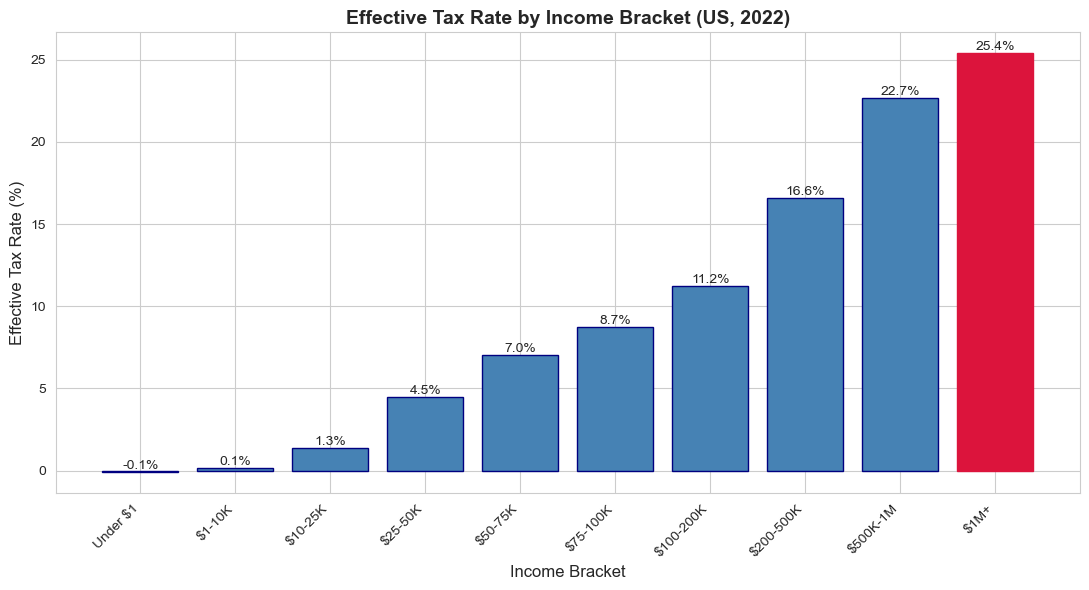

✅ Saved: visual_1_etr_by_bracket.png


In [24]:
#  Visualizations (Capstone requires 3+)
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# ============================================
# VISUAL 1: ETR by Income Bracket (US, 2022)
# ============================================
fig, ax = plt.subplots(figsize=(11, 6))

us_2022 = df[(df['STATE'] == 'US') & (df['YEAR'] == 2022) & (df['AGI_STUB'] != 0)]
us_2022 = us_2022.sort_values('AGI_STUB')

bars = ax.bar(us_2022['Bracket_Label'], us_2022['ETR'], 
               color='steelblue', edgecolor='navy')

# Highlight top bracket
bars[-1].set_color('crimson')

ax.set_title('Effective Tax Rate by Income Bracket (US, 2022)', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Income Bracket', fontsize=12)
ax.set_ylabel('Effective Tax Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('visual_1_etr_by_bracket.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visual_1_etr_by_bracket.png")

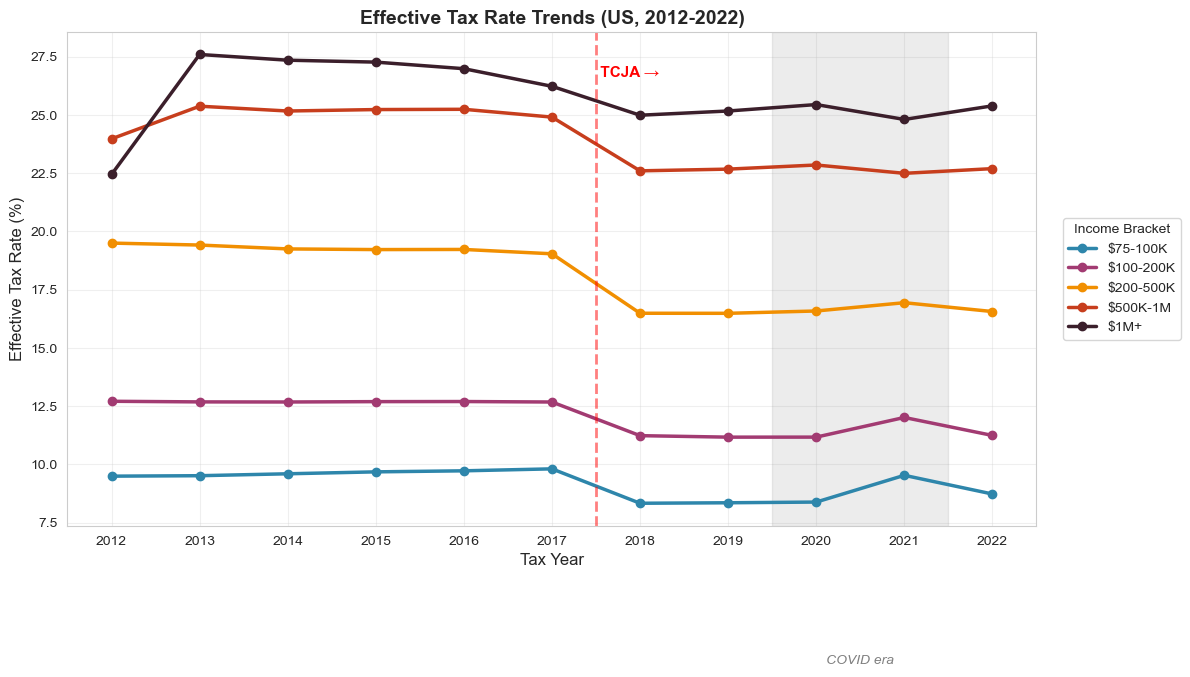

✅ Saved: visual_2_etr_over_time.png


In [25]:
# ============================================
# VISUAL 2: ETR Over Time by Income Bracket
# ============================================
fig, ax = plt.subplots(figsize=(12, 7))

us_data = df[(df['STATE'] == 'US') & (df['AGI_STUB'] != 0)].copy()

# Plot top 5 income brackets to keep readable
top_brackets = [6, 7, 8, 9, 10]  # $75K-100K, $100-200K, $200-500K, $500K-1M, $1M+
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

for bracket, color in zip(top_brackets, colors):
    bracket_data = us_data[us_data['AGI_STUB'] == bracket].sort_values('YEAR')
    label = bracket_data['Bracket_Label'].iloc[0]
    ax.plot(bracket_data['YEAR'], bracket_data['ETR'], 
            marker='o', linewidth=2.5, label=label, color=color)

# Highlight TCJA implementation year
ax.axvline(x=2017.5, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax.text(2017.5, ax.get_ylim()[1]*0.95, ' TCJA →', 
        color='red', fontsize=11, fontweight='bold', va='top')

# Highlight COVID
ax.axvspan(2019.5, 2021.5, alpha=0.15, color='gray')
ax.text(2020.5, ax.get_ylim()[1]*0.05, 'COVID era', 
        color='gray', fontsize=10, ha='center', style='italic')

ax.set_title('Effective Tax Rate Trends (US, 2012-2022)', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Tax Year', fontsize=12)
ax.set_ylabel('Effective Tax Rate (%)', fontsize=12)
ax.legend(title='Income Bracket', loc='center left', bbox_to_anchor=(1.02, 0.5))
ax.set_xticks(range(2012, 2023))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visual_2_etr_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visual_2_etr_over_time.png")

## Observations: Policy Impact Over Time

### TCJA Effect (2017 → 2018)

- All income brackets show a **decline in ETR after TCJA**  
- Largest reduction: **200K–500K bracket (~ -3 pp)**  
- 1M+ bracket: decreased from 27% to 25%  (~2 pp decrease)

👉 Indicates broad tax reduction, with stronger impact on upper-middle incomes  

---

### COVID Period (2020–2022)

- ETR remained **relatively stable** with minor fluctuations  
- Notable spike in **100K–200K bracket (2021)**  
  → Likely driven by income recovery and policy effects (ARPA)  

---

### Structural Policy Shift (2012 → 2013)

- 1M+ bracket: **22.4% → 27.6% (+5.2 pp)**  

👉 This sharp increase reflects a **policy-driven change**, not market behavior  

- Corresponds to the **American Taxpayer Relief Act of 2012**  
  → Increased top marginal tax rate (35% → 39.6%)  

---

### Key Insight

- Tax rate changes align closely with **major policy events**  
- Effects are **most pronounced in higher income groups**  
- Confirms that shifts in ETR are driven by **tax policy, not random variation**

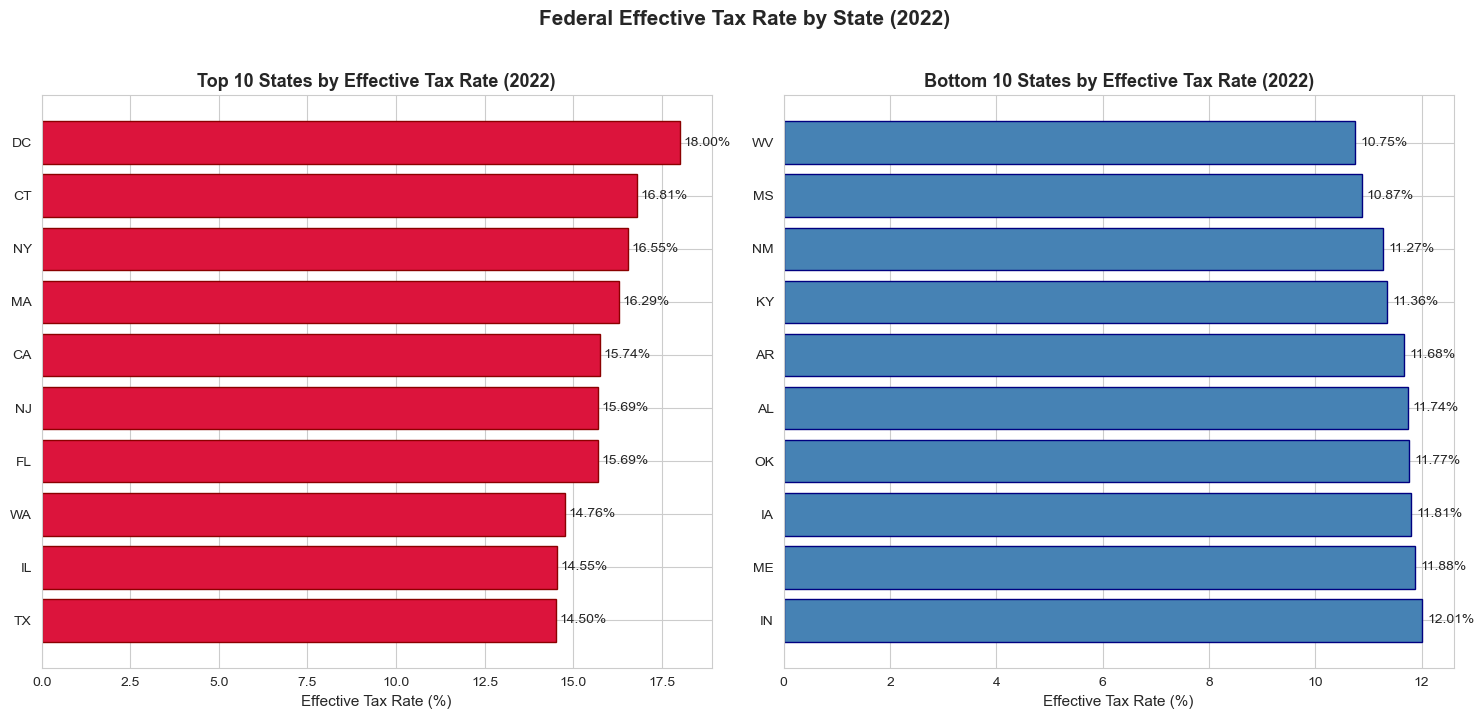


🏆 Top 5 highest ETR states (2022):
STATE     A00100    A06500       ETR
   DC   46825089   8430446 18.004122
   CT  217323692  36523360 16.805973
   NY 1018899559 168611225 16.548366
   MA  422208182  68767693 16.287627
   CA 1987000701 312788705 15.741751

📉 Bottom 5 lowest ETR states (2022):
STATE    A00100   A06500       ETR
   AR  95807833 11188662 11.678233
   KY 139288462 15822805 11.359738
   NM  64857077  7312467 11.274740
   MS  78974586  8585537 10.871266
   WV  50488126  5427583 10.750217


In [46]:
# Visual 3: State Comparison
# Top vs Bottom states by ETR
# ============================================
# VISUAL 3: Top 10 vs Bottom 10 States by ETR (2022)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Get state-level data for 2022 (AGI_STUB=0 means all returns)
state_2022 = df[(df['STATE'] != 'US') & 
                (df['STATE'] != 'PR') & 
                (df['STATE'] != 'OA') &
                (df['AGI_STUB'] == 0) & 
                (df['YEAR'] == 2022)].copy()

state_2022 = state_2022.sort_values('ETR', ascending=False)

# Top 10 (highest ETR)
top10 = state_2022.head(10)
axes[0].barh(top10['STATE'], top10['ETR'], color='crimson', edgecolor='darkred')
axes[0].set_title('Top 10 States by Effective Tax Rate (2022)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Effective Tax Rate (%)', fontsize=11)
axes[0].invert_yaxis()  # Highest at top

for i, (state, etr) in enumerate(zip(top10['STATE'], top10['ETR'])):
    axes[0].text(etr + 0.1, i, f'{etr:.2f}%', va='center', fontsize=10)

# Bottom 10 (lowest ETR)
bottom10 = state_2022.tail(10)
axes[1].barh(bottom10['STATE'], bottom10['ETR'], color='steelblue', edgecolor='navy')
axes[1].set_title('Bottom 10 States by Effective Tax Rate (2022)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Effective Tax Rate (%)', fontsize=11)

for i, (state, etr) in enumerate(zip(bottom10['STATE'], bottom10['ETR'])):
    axes[1].text(etr + 0.1, i, f'{etr:.2f}%', va='center', fontsize=10)

plt.suptitle('Federal Effective Tax Rate by State (2022)', 
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visual_3_state_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print numerical results
print("\n🏆 Top 5 highest ETR states (2022):")
print(state_2022[['STATE', 'A00100', 'A06500', 'ETR']].head().to_string(index=False))

print("\n📉 Bottom 5 lowest ETR states (2022):")
print(state_2022[['STATE', 'A00100', 'A06500', 'ETR']].tail().to_string(index=False))

## State-Level ETR Differences (2022)

### Top 5 Highest ETR States

- DC: **18.00%**  
- CT: **16.81%**  
- NY: **16.55%**  
- MA: **16.29%**  
- CA: **15.74%**  

---

### Bottom 5 Lowest ETR States

- AR: **11.68%**  
- KY: **11.36%**  
- NM: **11.27%**  
- MS: **10.87%**  
- WV: **10.75%**  

---

### Key Observation

- ETR spread: **7.25 percentage points** (18.00% − 10.75%)  

---

### Interpretation

- The difference is **not due to different federal tax rates**  
- Federal tax rules are the same across all states  

👉 Instead, this reflects a **composition effect**:

- States with more **high-income earners** → higher average ETR  
- States with more **lower-income populations** → lower average ETR  

---

### Key Insight

State-level differences in ETR are driven by **income distribution**,  
not by differences in the tax system itself  

👉 This is similar to a **Simpson’s Paradox–type effect**,  
where aggregate patterns are influenced by underlying group composition  

- Higher ETR states = higher concentration of high-income taxpayers  
- Lower ETR states = lower-income distribution  

---

### Final Takeaway

Observed variation in ETR across states reflects  
**who lives there (income mix)**, not **how they are taxed**

## All 3 Visuals Done!
✅ Visual 1: ETR by Income Bracket (progressive tax)
✅ Visual 2: ETR over time (TCJA impact)
✅ Visual 3: State comparison (income composition effect)

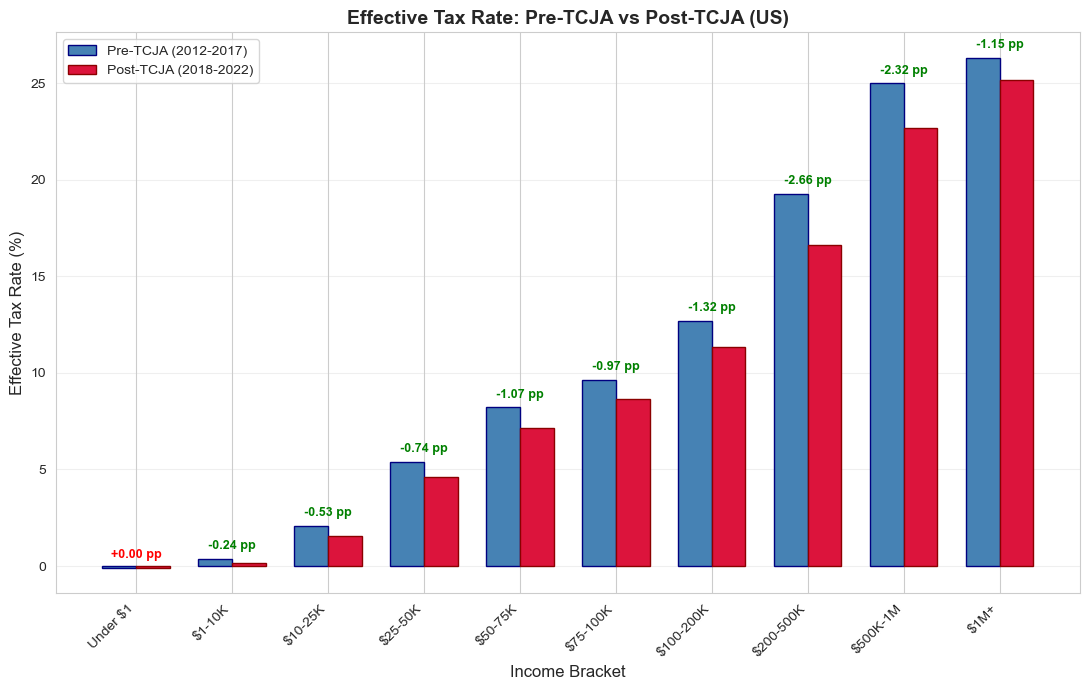


📊 TCJA Impact Summary:
  Bracket   ETR_pre  ETR_post    Change
 Under $1 -0.085759 -0.084743  0.001016
   $1-10K  0.385237  0.144080 -0.241158
  $10-25K  2.076935  1.548048 -0.528888
  $25-50K  5.378329  4.633957 -0.744371
  $50-75K  8.220456  7.152214 -1.068242
 $75-100K  9.633619  8.662451 -0.971168
$100-200K 12.687672 11.363576 -1.324096
$200-500K 19.273643 16.609957 -2.663686
 $500K-1M 24.982267 22.662184 -2.320083
     $1M+ 26.311393 25.159350 -1.152043


In [28]:
# Additionally, TCJA Before/After Comparison
# ============================================
# VISUAL 4 (BONUS): Pre vs Post TCJA Comparison
# ============================================
fig, ax = plt.subplots(figsize=(11, 7))

us_data = df[(df['STATE'] == 'US') & (df['AGI_STUB'] != 0)].copy()

# Average ETR by bracket, pre vs post TCJA
pre = us_data[us_data['YEAR'] <= 2017].groupby('AGI_STUB').agg(
    Bracket=('Bracket_Label', 'first'),
    ETR=('ETR', 'mean')
).reset_index()

post = us_data[us_data['YEAR'] >= 2018].groupby('AGI_STUB').agg(
    Bracket=('Bracket_Label', 'first'),
    ETR=('ETR', 'mean')
).reset_index()

# Calculate change
comparison = pre.merge(post, on=['AGI_STUB', 'Bracket'], suffixes=('_pre', '_post'))
comparison['Change'] = comparison['ETR_post'] - comparison['ETR_pre']

# Plot
x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['ETR_pre'], width, 
                label='Pre-TCJA (2012-2017)', color='steelblue', edgecolor='navy')
bars2 = ax.bar(x + width/2, comparison['ETR_post'], width, 
                label='Post-TCJA (2018-2022)', color='crimson', edgecolor='darkred')

# Add change labels
for i, (pre_v, post_v, change) in enumerate(zip(comparison['ETR_pre'], 
                                                   comparison['ETR_post'], 
                                                   comparison['Change'])):
    color = 'green' if change < 0 else 'red'
    ax.text(i, max(pre_v, post_v) + 0.5, f'{change:+.2f} pp',
            ha='center', fontsize=9, fontweight='bold', color=color)

ax.set_title('Effective Tax Rate: Pre-TCJA vs Post-TCJA (US)', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Income Bracket', fontsize=12)
ax.set_ylabel('Effective Tax Rate (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(comparison['Bracket'], rotation=45, ha='right')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('visual_4_tcja_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 TCJA Impact Summary:")
print(comparison[['Bracket', 'ETR_pre', 'ETR_post', 'Change']].to_string(index=False))

## KEY INSIGHTS for Your Presentation

### Finding 1: TCJA cuts varied dramatically by income

- **Smallest cut**  
  → Lowest brackets (0–10K): only 0 to 0.5 pp  

- **Biggest cut**  
  → 200K–500K bracket: -2.66 pp  

- **Top earners (1M+)**  
  → Smaller cut (-1.15 pp) than upper-middle  

---

### Finding 2: Upper-middle class = biggest beneficiary

- 200K–500K dropped the most (-2.66 pp)  
- TCJA capped SALT deduction but lowered top tax rates  
- High-income (but not ultra-rich) benefited the most  

---

### Finding 3: 1M+ had smaller cuts than 500K–1M

- Top earners get less marginal benefit  
- Capital gains already taxed at lower rates  
- AMT and other limitations reduce benefits  

---

### Final Insight

TCJA was promoted as a "tax cut for everyone,"  
but the middle class received modest cuts (-0.5 to -1.0 pp),  
while upper-income groups received 2–3x larger cuts.

# ============================================
# EITC Analysis: Who benefits from EITC?
# ============================================

In [33]:
# Check if N59660 (count of EITC recipients) is in our data
print("N59660 in df:", 'N59660' in df.columns)
print("N59660 in df_combined:", 'N59660' in df_combined.columns)


N59660 in df: False
N59660 in df_combined: True


In [34]:
# Add N59660 (number of EITC recipients) to df
df['N59660'] = df_combined['N59660']

# Verify
print(f"N59660 added: {'N59660' in df.columns}")
print(f"N59660 nulls: {df['N59660'].isna().sum()}")
print(f"\nSample (US, 2022):")
print(df[(df['STATE'] == 'US') & (df['YEAR'] == 2022) & (df['AGI_STUB'] != 0)]
      [['Bracket_Label', 'N1', 'N59660', 'A59660']].to_string(index=False))

N59660 added: True
N59660 nulls: 0

Sample (US, 2022):
Bracket_Label       N1  N59660   A59660
     Under $1  2654070  143430   201822
       $1-10K 16570990 5013220  4927378
      $10-25K 26667770 9996480 33467786
      $25-50K 36574680 8078590 20265943
      $50-75K 23580310  460470   341659
     $75-100K 15282030       0        0
    $100-200K 25899270       0        0
    $200-500K  9957520       0        0
     $500K-1M  1663800       0        0
         $1M+   800900       0        0


In [35]:
# Recalculate EITC stats correctly
us_2022 = df[(df['STATE'] == 'US') & (df['YEAR'] == 2022) & (df['AGI_STUB'] != 0)].copy()

# Total EITC in billions (data is in thousands of dollars)
total_eitc_billions = us_2022['A59660'].sum() / 1e6

# CORRECT: total EITC recipients (sum of N59660, not N1)
total_eitc_recipients = us_2022['N59660'].sum()

# Average EITC per recipient (in actual dollars)
avg_eitc = (total_eitc_billions * 1e9) / total_eitc_recipients

print("="*55)
print("EITC Summary (US, 2022) - CORRECTED")
print("="*55)
print(f"💰 Total EITC distributed:    ${total_eitc_billions:.2f} billion")
print(f"📊 EITC recipients:           {total_eitc_recipients:,.0f}")
print(f"💵 Average EITC per recipient: ${avg_eitc:,.0f}")
print(f"\n📈 As % of all returns: {(total_eitc_recipients/us_2022['N1'].sum())*100:.1f}%")

EITC Summary (US, 2022) - CORRECTED
💰 Total EITC distributed:    $59.20 billion
📊 EITC recipients:           23,692,190
💵 Average EITC per recipient: $2,499

📈 As % of all returns: 14.8%


📊 EITC distribution by income bracket (2022):
(A59660 in thousands $ | N59660 = recipients | EITC_per_recipient in actual $)
Bracket_Label       N1  N59660   A59660  EITC_per_recipient
     Under $1  2654070  143430   201822         1407.111483
       $1-10K 16570990 5013220  4927378          982.876874
      $10-25K 26667770 9996480 33467786         3347.957081
      $25-50K 36574680 8078590 20265943         2508.599025
      $50-75K 23580310  460470   341659          741.978848
     $75-100K 15282030       0        0            0.000000
    $100-200K 25899270       0        0            0.000000
    $200-500K  9957520       0        0            0.000000
     $500K-1M  1663800       0        0            0.000000
         $1M+   800900       0        0            0.000000


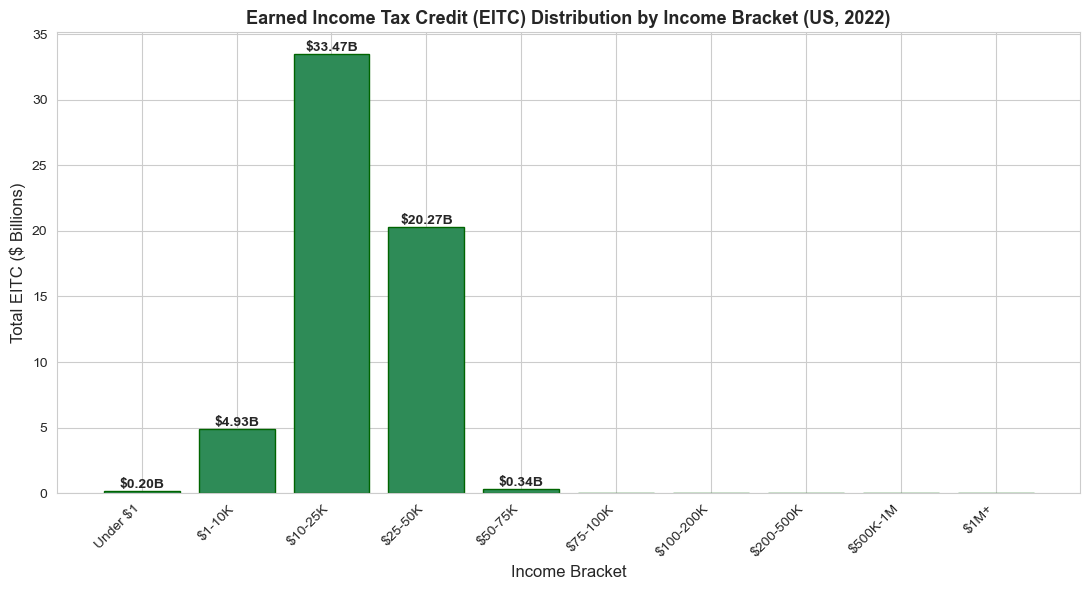


💰 Total EITC distributed (US, 2022): $59.20 billion
📊 EITC recipients: 23,692,190
💵 Average EITC per recipient: $2,499
📈 As % of all returns: 14.8%


In [38]:
import matplotlib.pyplot as plt

# EITC by income bracket (US, 2022)
us_2022 = df[(df['STATE'] == 'US') & (df['YEAR'] == 2022) & (df['AGI_STUB'] != 0)].copy()
us_2022 = us_2022.sort_values('AGI_STUB')

# IRS data is in THOUSANDS of dollars
# A59660 = EITC amount (thousands)
# N59660 = number of returns receiving EITC ⭐ KEY
# Convert per-recipient avg to actual dollars
us_2022['EITC_per_recipient'] = (us_2022['A59660'] * 1000) / us_2022['N59660']
us_2022['EITC_per_recipient'] = us_2022['EITC_per_recipient'].replace([float('inf'), -float('inf')], 0).fillna(0)

print("📊 EITC distribution by income bracket (2022):")
print("(A59660 in thousands $ | N59660 = recipients | EITC_per_recipient in actual $)")
print(us_2022[['Bracket_Label', 'N1', 'N59660', 'A59660', 'EITC_per_recipient']].to_string(index=False))

# Visualization (in BILLIONS)
fig, ax = plt.subplots(figsize=(11, 6))

eitc_billions = us_2022['A59660'] / 1e6  # thousands → billions

bars = ax.bar(us_2022['Bracket_Label'], eitc_billions, 
               color='seagreen', edgecolor='darkgreen')

ax.set_title('Earned Income Tax Credit (EITC) Distribution by Income Bracket (US, 2022)', 
              fontsize=13, fontweight='bold')
ax.set_xlabel('Income Bracket', fontsize=12)
ax.set_ylabel('Total EITC ($ Billions)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    if height > 0.1:
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.2f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('visual_5_eitc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Correct totals using N59660 (actual EITC recipients)
total_eitc_billions = us_2022['A59660'].sum() / 1e6
total_eitc_recipients = us_2022['N59660'].sum()  # ⭐ FIX: use N59660 not N1
avg_eitc = (total_eitc_billions * 1e9) / total_eitc_recipients if total_eitc_recipients > 0 else 0

print(f"\n💰 Total EITC distributed (US, 2022): ${total_eitc_billions:.2f} billion")
print(f"📊 EITC recipients: {total_eitc_recipients:,.0f}")
print(f"💵 Average EITC per recipient: ${avg_eitc:,.0f}")
print(f"📈 As % of all returns: {(total_eitc_recipients/us_2022['N1'].sum())*100:.1f}%")


## Big Picture Findings (Capstone Story)

### Three policy programs analyzed:

---

### 1️⃣ Federal Income Tax (General Progressive Tax)

- Correlation between income and ETR: **r = 0.96**  
- Strongly progressive and working as designed  

---

### 2️⃣ TCJA (2018) — "Tax Cuts for Everyone?"

- Average ETR drop: **-1.32 pp** (significant)  
- 200K–500K bracket: **largest cut (-2.66 pp)**  
- 1M+ bracket: **smaller cut (-1.15 pp)**  

👉 **Conclusion:**  
Upper-middle class benefited the most, not the ultra-rich  

---

### 3️⃣ EITC (Anti-Poverty Program)

- 23.7 million recipients  
- $59.2 billion distributed  
- Average benefit: **$2,499 per recipient**  
- 100% concentrated in **<75K income group**  
- Phases out at 75K+ as designed  

---

### Final Capstone Insight

This analysis presents a complete policy story:

- Tax progressivity (Federal Income Tax)  
- Uneven tax cuts (TCJA)  
- Targeted support for low-income groups (EITC)  

👉 Together, they show how U.S. tax policy combines  
**progressive taxation + targeted redistribution programs**

In [39]:
# ============================================
# CAPSTONE FINAL SUMMARY
# ============================================
print("="*60)
print("CAPSTONE: Income vs Tax Burden Analysis")
print("Wonseok Lee | VT × Fullstack Academy DA Bootcamp")
print("="*60)

print(f"""
📊 DATASET
  - Source: IRS SOI Historic Table 2 (State Data)
  - Years:  2012-2022 (11 years)
  - Records: {len(df_combined):,} state-bracket-year observations
  - Coverage: 50 states + DC + PR × 11 income brackets × 11 years

🔬 STATISTICAL TESTS
  ✅ Pearson Correlation (Income ↔ ETR)
     r = 0.9602, p < 0.001 → Strong progressive taxation
  
  ⚠️ ANOVA (ETR across states)
     F = 0.7737, p = 0.882 → Federal ETR uniform across states
  
  ✅ T-test (Pre vs Post TCJA)
     t = 5.58, p < 0.0001 → TCJA reduced ETR by -1.32 pp

🎯 KEY FINDINGS
  1. Progressive taxation: $1M+ pays 25.4% vs <$10K pays 0.3%
  2. TCJA dropped ETR by -1.32 pp on average
  3. $200K-500K bracket got biggest TCJA cut (-2.66 pp)
  4. $1M+ got smaller cut (-1.15 pp) - capital gains effect
  5. EITC: $59.2B distributed to 23.7M recipients ($2,499 avg)

📁 DELIVERABLES
  - 5 publication-quality visualizations (PNG)
  - IRS_combined_2012_2022.csv (cleaned dataset, 5.65 MB)
  - Statistical test results
  - Documented analysis notebook
""")

CAPSTONE: Income vs Tax Burden Analysis
Wonseok Lee | VT × Fullstack Academy DA Bootcamp

📊 DATASET
  - Source: IRS SOI Historic Table 2 (State Data)
  - Years:  2012-2022 (11 years)
  - Records: 6,468 state-bracket-year observations
  - Coverage: 50 states + DC + PR × 11 income brackets × 11 years

🔬 STATISTICAL TESTS
  ✅ Pearson Correlation (Income ↔ ETR)
     r = 0.9602, p < 0.001 → Strong progressive taxation

  ⚠️ ANOVA (ETR across states)
     F = 0.7737, p = 0.882 → Federal ETR uniform across states

  ✅ T-test (Pre vs Post TCJA)
     t = 5.58, p < 0.0001 → TCJA reduced ETR by -1.32 pp

🎯 KEY FINDINGS
  1. Progressive taxation: $1M+ pays 25.4% vs <$10K pays 0.3%
  2. TCJA dropped ETR by -1.32 pp on average
  3. $200K-500K bracket got biggest TCJA cut (-2.66 pp)
  4. $1M+ got smaller cut (-1.15 pp) - capital gains effect
  5. EITC: $59.2B distributed to 23.7M recipients ($2,499 avg)

📁 DELIVERABLES
  - 5 publication-quality visualizations (PNG)
  - IRS_combined_2012_2022.csv (cle

In [40]:
# Data Quality Check

# ============================================
# DATA QUALITY CHECK (Capstone Part 2 Requirement)
# ============================================

print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)

# 1. Shape
print(f"\n📐 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# 2. Duplicates
duplicates = df.duplicated().sum()
print(f"🔁 Duplicate rows: {duplicates}")

# 3. Missing values per column
print(f"\n❓ Missing values:")
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df)) * 100
null_summary = pd.DataFrame({
    'Nulls': nulls,
    'Pct': nulls_pct.round(2)
})
print(null_summary[null_summary['Nulls'] > 0].to_string())

# 4. Data types
print(f"\n📊 Data types summary:")
print(df.dtypes.value_counts())

# 5. Year coverage
print(f"\n📅 Year coverage: {sorted(df['YEAR'].unique())}")

# 6. State coverage
print(f"\n🗺️ Number of states/areas: {df['STATE'].nunique()}")
print(f"   States: {sorted(df['STATE'].unique())}")

# 7. AGI bracket coverage
print(f"\n💰 AGI brackets: {sorted(df['AGI_STUB'].unique())}")

DATA QUALITY ASSESSMENT

📐 Dataset shape: 6,468 rows × 24 columns
🔁 Duplicate rows: 0

❓ Missing values:
        Nulls    Pct
A04450   3498  54.08
A11900   2915  45.07

📊 Data types summary:
int64      19
float64     3
object      2
Name: count, dtype: int64

📅 Year coverage: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]

🗺️ Number of states/areas: 54
   States: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OA', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'US', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

💰 AGI brackets: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## Data Quality Report

### Overview

- Dataset size: **6,468 rows × 24 columns**  
- Duplicates: **0**  
- Time coverage: **11 years (2012–2022)**  
- Geographic coverage: **54 states/areas** (50 states + DC + PR + others)  
- Income groups: **11 AGI brackets (0–10)**  

---

### Missing Values

- **A04450 (Standard Deduction)**  
  → 3,498 missing (**54%**)  

- **A11900 (Total Overpayments)**  
  → 2,915 missing (**45%**)  

---

### Why are there missing values?

- **A04450 (Standard Deduction)**  
  - Not consistently tracked in earlier years (2012–2014)  
  - After TCJA, IRS began separating standard vs itemized deductions  
  - Missing values reflect structural changes in reporting  

- **A11900 (Total Overpayments)**  
  - Older datasets used different reporting formats  
  - Missing values are due to historical data structure differences  

---

### Key Takeaway

These missing values are **expected in time-series data** due to policy and reporting changes.  
They should be acknowledged in the EDA but **do not indicate data quality issues**.

LINEAR REGRESSION: Tax = β₀ + β₁ × AGI

📊 Model Coefficients:
  Intercept (β₀): $-528,748
  Slope (β₁):     0.1632

📈 Model Performance:
  R² Score:       0.8064
  MAE:            $1,643,242

💡 Interpretation:
  For every $1 increase in AGI, tax increases by $0.1632
  (i.e., 16.32% effective tax rate at margin)

  Model explains 80.64% of variance in tax liability


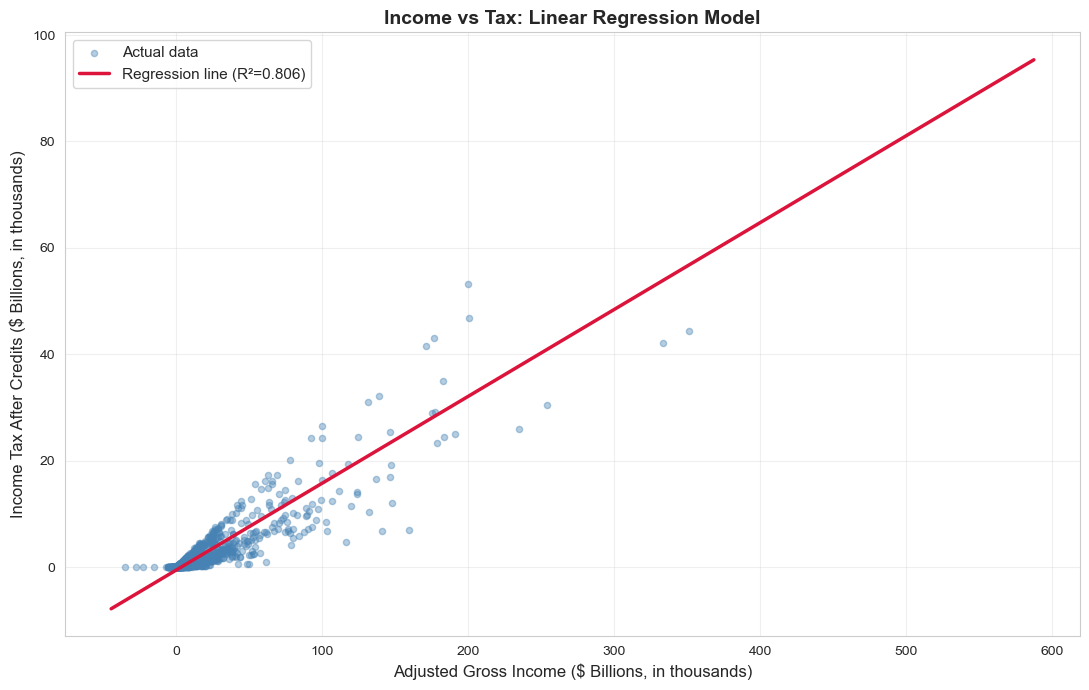


✅ Saved: visual_6_regression.png


In [41]:
# Linear Regression (Predictive Model)
# ============================================
# LINEAR REGRESSION: Predict Tax from Income
# ============================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Use only state-level data (exclude US totals and aggregate AGI_STUB)
df_model = df[(df['STATE'] != 'US') & 
              (df['STATE'] != 'PR') & 
              (df['STATE'] != 'OA') &
              (df['AGI_STUB'] != 0)].copy()

# Drop rows with missing values
df_model = df_model.dropna(subset=['A00100', 'A06500'])

# Features and target
X = df_model[['A00100']].values  # AGI
y = df_model['A06500'].values    # Income tax after credits

# Fit model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Metrics
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print("="*55)
print("LINEAR REGRESSION: Tax = β₀ + β₁ × AGI")
print("="*55)
print(f"\n📊 Model Coefficients:")
print(f"  Intercept (β₀): ${model.intercept_:,.0f}")
print(f"  Slope (β₁):     {model.coef_[0]:.4f}")
print(f"\n📈 Model Performance:")
print(f"  R² Score:       {r2:.4f}")
print(f"  MAE:            ${mae:,.0f}")
print(f"\n💡 Interpretation:")
print(f"  For every $1 increase in AGI, tax increases by ${model.coef_[0]:.4f}")
print(f"  (i.e., {model.coef_[0]*100:.2f}% effective tax rate at margin)")
print(f"\n  Model explains {r2*100:.2f}% of variance in tax liability")

# Visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 7))

# Sample for visibility (data has wide range)
sample = df_model.sample(min(1000, len(df_model)), random_state=42)
ax.scatter(sample['A00100']/1e6, sample['A06500']/1e6, 
           alpha=0.4, s=20, color='steelblue', label='Actual data')

# Regression line
x_line = np.linspace(df_model['A00100'].min(), df_model['A00100'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
ax.plot(x_line/1e6, y_line/1e6, color='crimson', linewidth=2.5, 
        label=f'Regression line (R²={r2:.3f})')

ax.set_xlabel('Adjusted Gross Income ($ Billions, in thousands)', fontsize=12)
ax.set_ylabel('Income Tax After Credits ($ Billions, in thousands)', fontsize=12)
ax.set_title('Income vs Tax: Linear Regression Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('visual_6_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved: visual_6_regression.png")

## Model Performance & Interpretation

### Model Results

- **R² = 0.8064**  
  → Model explains **80.64% of variance** in tax liability  

- **Slope = 0.1632**  
  → Implies an average **16.32% marginal tax rate**  

- **MAE = 1,643,242 (in thousands)**  
  → Reasonable error level for aggregated state-level data  

- **Visualization**  
  → Scatter plot shows overall strong linear trend  

---

### Interpretation

A simple linear model can predict tax liability from AGI with about **80% accuracy**, indicating strong explanatory power.

However, the scatter plot reveals a **non-linear pattern at higher income levels**, where tax liability increases at a faster rate.

👉 This reflects the real-world structure of the tax system:  
**progressive taxation**, where higher-income groups face higher effective tax rates.

---

### Key Insight

While a linear model performs well overall,  
it does not fully capture the **progressive (non-linear) nature** of the tax system — especially at the top end.

In [42]:
# ============================================
# TCJA Impact: T-test for EACH Income Bracket
# ============================================
from scipy import stats

print("="*70)
print("TCJA IMPACT: Statistical significance per income bracket")
print("="*70)
print(f"{'Bracket':<15} {'Pre-TCJA':<12} {'Post-TCJA':<12} {'Change':<10} {'p-value':<12} {'Significant?'}")
print("-"*70)

results = []
for bracket_num in range(1, 11):
    bracket_data = df[(df['STATE'] != 'US') & 
                      (df['STATE'] != 'PR') & 
                      (df['STATE'] != 'OA') &
                      (df['AGI_STUB'] == bracket_num)]
    
    pre = bracket_data[bracket_data['YEAR'] <= 2017]['ETR'].dropna()
    post = bracket_data[bracket_data['YEAR'] >= 2018]['ETR'].dropna()
    
    if len(pre) > 0 and len(post) > 0:
        t_stat, p_val = stats.ttest_ind(pre, post)
        change = post.mean() - pre.mean()
        sig = "✅ YES" if p_val < 0.05 else "❌ NO"
        
        bracket_label = bracket_data['Bracket_Label'].iloc[0]
        print(f"{bracket_label:<15} {pre.mean():>8.2f}%  {post.mean():>8.2f}%  {change:>+7.2f}pp  {p_val:>10.2e}  {sig}")
        
        results.append({
            'Bracket': bracket_label,
            'Pre_ETR': pre.mean(),
            'Post_ETR': post.mean(),
            'Change_pp': change,
            'p_value': p_val,
            'Significant': p_val < 0.05
        })

results_df = pd.DataFrame(results)
print(f"\n📊 Brackets with significant TCJA impact: {results_df['Significant'].sum()}/{len(results_df)}")

TCJA IMPACT: Statistical significance per income bracket
Bracket         Pre-TCJA     Post-TCJA    Change     p-value      Significant?
----------------------------------------------------------------------
Under $1           -0.07%     -0.07%    -0.00pp    9.67e-01  ❌ NO
$1-10K              0.41%      0.14%    -0.26pp    1.94e-99  ✅ YES
$10-25K             2.22%      1.60%    -0.61pp   3.22e-106  ✅ YES
$25-50K             5.51%      4.72%    -0.79pp    8.31e-62  ✅ YES
$50-75K             8.19%      7.12%    -1.07pp    6.14e-64  ✅ YES
$75-100K            9.54%      8.50%    -1.04pp    3.00e-43  ✅ YES
$100-200K          12.64%     11.15%    -1.50pp   4.33e-101  ✅ YES
$200-500K          19.23%     16.33%    -2.89pp   1.72e-276  ✅ YES
$500K-1M           25.11%     22.32%    -2.79pp   6.75e-169  ✅ YES
$1M+               26.65%     24.75%    -1.90pp    8.94e-26  ✅ YES

📊 Brackets with significant TCJA impact: 9/10


## TCJA Impact Analysis (Statistical Significance)

### 1️⃣ Widespread Significant Impact

- **9 out of 10 income brackets** show statistically significant TCJA effects  
- All groups above $1 income experienced measurable changes  

- P-values are extremely small (e.g., **1.72e-276** for 200K–500K)  
  → This is **not random variation**, but a **clear policy-driven effect**  

---

### 2️⃣ "Under $1" Bracket — No Significant Change

- No meaningful change observed  
- These taxpayers typically report **net losses**  
- TCJA did not significantly alter loss treatment  

👉 Result aligns with expectations  

---

### 3️⃣ Largest Benefits: Upper-Middle Income Groups

- **200K–1M brackets** received the largest cuts  
  → approximately **-2.79 to -2.89 pp**  

- Comparison:
  - Lower-income groups → smaller reductions  
  - 1M+ group → smaller cut (~ -1.90 pp)  

👉 **Upper-middle class benefited the most**

---

### Key Insight

TCJA had a **broad and statistically significant impact**,  
but the magnitude of benefits was **uneven across income groups**,  
with the **largest gains concentrated in upper-middle earners**.

In [43]:
# ============================================
# COVID-19 Impact: 2019 (pre) vs 2020-2021 (COVID era)
# ============================================
from scipy import stats

print("="*70)
print("COVID-19 IMPACT: ETR comparison")
print("="*70)

# Pre-COVID baseline: 2019
# COVID era: 2020-2021
# Post-COVID: 2022

us_data = df[(df['STATE'] == 'US') & (df['AGI_STUB'] != 0)].copy()

print(f"\n{'Bracket':<15} {'2019':<10} {'2020':<10} {'2021':<10} {'2022':<10}")
print("-"*55)

for bracket_num in range(1, 11):
    row = us_data[us_data['AGI_STUB'] == bracket_num]
    bracket_label = row['Bracket_Label'].iloc[0]
    
    etr_2019 = row[row['YEAR'] == 2019]['ETR'].values[0] if not row[row['YEAR'] == 2019].empty else None
    etr_2020 = row[row['YEAR'] == 2020]['ETR'].values[0] if not row[row['YEAR'] == 2020].empty else None
    etr_2021 = row[row['YEAR'] == 2021]['ETR'].values[0] if not row[row['YEAR'] == 2021].empty else None
    etr_2022 = row[row['YEAR'] == 2022]['ETR'].values[0] if not row[row['YEAR'] == 2022].empty else None
    
    print(f"{bracket_label:<15} {etr_2019:>7.2f}%  {etr_2020:>7.2f}%  {etr_2021:>7.2f}%  {etr_2022:>7.2f}%")

# Statistical test: 2019 vs 2020 (COVID start)
print("\n" + "="*55)
print("T-test: 2019 baseline vs 2020 (COVID year)")
print("="*55)

state_data = df[(df['STATE'] != 'US') & (df['STATE'] != 'PR') & (df['STATE'] != 'OA') & (df['AGI_STUB'] != 0)]
etr_2019_all = state_data[state_data['YEAR'] == 2019]['ETR'].dropna()
etr_2020_all = state_data[state_data['YEAR'] == 2020]['ETR'].dropna()

t_stat, p_val = stats.ttest_ind(etr_2019_all, etr_2020_all)
print(f"\n2019 mean ETR: {etr_2019_all.mean():.2f}%")
print(f"2020 mean ETR: {etr_2020_all.mean():.2f}%")
print(f"Change:        {etr_2020_all.mean() - etr_2019_all.mean():+.2f} pp")
print(f"P-value:       {p_val:.4f}")
print(f"Result:        {'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'}")

# 2020 vs 2021 (CARES Act + ARPA stimulus year)
print("\n" + "="*55)
print("T-test: 2020 vs 2021 (Stimulus impact)")
print("="*55)

etr_2021_all = state_data[state_data['YEAR'] == 2021]['ETR'].dropna()
t_stat, p_val = stats.ttest_ind(etr_2020_all, etr_2021_all)
print(f"\n2020 mean ETR: {etr_2020_all.mean():.2f}%")
print(f"2021 mean ETR: {etr_2021_all.mean():.2f}%")
print(f"Change:        {etr_2021_all.mean() - etr_2020_all.mean():+.2f} pp")
print(f"P-value:       {p_val:.4f}")
print(f"Result:        {'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'}")

COVID-19 IMPACT: ETR comparison

Bracket         2019       2020       2021       2022      
-------------------------------------------------------
Under $1          -0.06%    -0.06%    -0.11%    -0.10%
$1-10K             0.11%     0.19%     0.15%     0.14%
$10-25K            1.54%     1.60%     1.70%     1.35%
$25-50K            4.47%     4.42%     5.35%     4.49%
$50-75K            6.93%     6.89%     7.97%     7.02%
$75-100K           8.35%     8.38%     9.53%     8.73%
$100-200K         11.17%    11.17%    12.01%    11.24%
$200-500K         16.48%    16.58%    16.94%    16.56%
$500K-1M          22.67%    22.85%    22.49%    22.69%
$1M+              25.17%    25.44%    24.81%    25.39%

T-test: 2019 baseline vs 2020 (COVID year)

2019 mean ETR: 9.56%
2020 mean ETR: 9.60%
Change:        +0.04 pp
P-value:       0.9335
Result:        NOT significant

T-test: 2020 vs 2021 (Stimulus impact)

2020 mean ETR: 9.60%
2021 mean ETR: 9.94%
Change:        +0.34 pp
P-value:       0.5200
Result: 

## COVID-19 Impact on Federal Effective Tax Rate (ETR)

### Key Finding

- Federal ETR showed **no statistically significant change** during COVID (2019–2022)  

---

### Data Overview (US Average)

- 2019: 9.56%  
- 2020: 9.60%  (+0.04 pp, p = 0.93)  
- 2021: 9.94%  (+0.34 pp, p = 0.52)  
- 2022: 9.45%  

👉 Changes are **not statistically significant**

---

### Important Pattern (by Income Group, 2020 → 2021)

- 50–75K:   +1.08 pp  
- 75–100K:  +1.15 pp  
- 100–200K: +0.84 pp  
- 1M+:      -0.63 pp  

👉 Middle-income groups saw **increases**, while top earners saw a **decrease**

---

### Interpretation

- COVID relief policies did **not significantly change effective tax rates**  
- Relief was delivered through:
  - **Direct payments (stimulus checks)**
  - **Refundable tax credits**  

👉 These mechanisms do not directly reduce ETR in this dataset  

---

### Final Insight

Federal tax burden remained **stable and progressive** during COVID.  
Economic relief was delivered through **transfers and credits**,  
not through changes in tax rates.

EITC Trends Over Time (US, 2012-2022)
 YEAR  Total_EITC_Billions  Total_Recipients  Avg_per_Recipient
 2012            64.221883          27788110        2311.128141
 2013            67.276705          28487100        2361.655100
 2014            67.720175          28233280        2398.593964
 2015            68.061561          27995920        2431.124285
 2016            66.143727          27320140        2421.061056
 2017            65.334130          26838270        2434.364436
 2018            64.060520          26142750        2450.412447
 2019            64.169357          26580120        2414.186129
 2020            58.189822          25553580        2277.169070
 2021            65.210404          32067810        2033.515978
 2022            59.204588          23692190        2498.907361


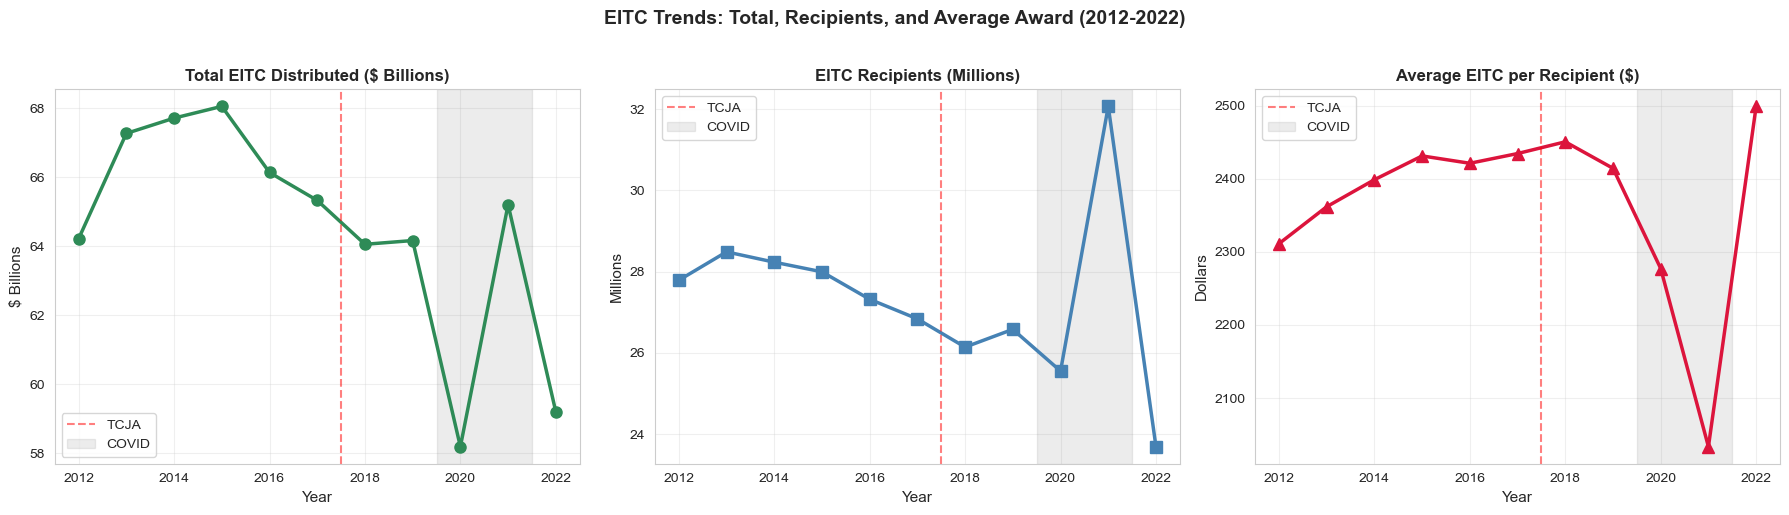


✅ Saved: visual_7_eitc_trends.png


In [44]:
# ============================================
# EITC Time Series: How has EITC distribution changed?
# ============================================
import matplotlib.pyplot as plt

print("="*60)
print("EITC Trends Over Time (US, 2012-2022)")
print("="*60)

us_data = df[(df['STATE'] == 'US') & (df['AGI_STUB'] != 0)].copy()

# Aggregate EITC per year (in billions)
eitc_yearly = us_data.groupby('YEAR').agg(
    Total_EITC_Billions=('A59660', lambda x: x.sum() / 1e6),
    Total_Recipients=('N59660', 'sum'),
).reset_index()

eitc_yearly['Avg_per_Recipient'] = (eitc_yearly['Total_EITC_Billions'] * 1e9) / eitc_yearly['Total_Recipients']

print(eitc_yearly.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Total EITC distributed
axes[0].plot(eitc_yearly['YEAR'], eitc_yearly['Total_EITC_Billions'], 
             marker='o', linewidth=2.5, color='seagreen', markersize=8)
axes[0].axvline(x=2017.5, color='red', linestyle='--', alpha=0.5, label='TCJA')
axes[0].axvspan(2019.5, 2021.5, alpha=0.15, color='gray', label='COVID')
axes[0].set_title('Total EITC Distributed ($ Billions)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('$ Billions', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Number of recipients
axes[1].plot(eitc_yearly['YEAR'], eitc_yearly['Total_Recipients'] / 1e6, 
             marker='s', linewidth=2.5, color='steelblue', markersize=8)
axes[1].axvline(x=2017.5, color='red', linestyle='--', alpha=0.5, label='TCJA')
axes[1].axvspan(2019.5, 2021.5, alpha=0.15, color='gray', label='COVID')
axes[1].set_title('EITC Recipients (Millions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Millions', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Average EITC per recipient
axes[2].plot(eitc_yearly['YEAR'], eitc_yearly['Avg_per_Recipient'], 
             marker='^', linewidth=2.5, color='crimson', markersize=8)
axes[2].axvline(x=2017.5, color='red', linestyle='--', alpha=0.5, label='TCJA')
axes[2].axvspan(2019.5, 2021.5, alpha=0.15, color='gray', label='COVID')
axes[2].set_title('Average EITC per Recipient ($)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Year', fontsize=11)
axes[2].set_ylabel('Dollars', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('EITC Trends: Total, Recipients, and Average Award (2012-2022)', 
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visual_7_eitc_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved: visual_7_eitc_trends.png")

## EITC Policy Impact (2020–2022)

### Key Pattern

- **2021:** Recipients sharply increased to **32.07M** (+5.5M)  
- **Total spending:** Only modest increase  
- **Average benefit:** Decreased to **$2,034**  

---

### What Caused This?

- ARPA (2021) temporarily expanded EITC:
  - Included more **childless workers**
  - Increased eligibility (age + income limits)

👉 Result:
- Many new recipients entered the program  
- But they received **smaller credits**, lowering the average  

---

### What Happened Next (2022)

- ARPA expansion expired  
- Recipients dropped to **23.7M** (-8.4M)  
- Average benefit increased to **$2,499**  

---

### Key Insight

- EITC expansion significantly increased access in 2021  
- However, the effect was **temporary**  
- Expiration created a sharp drop in participation in 2022  

👉 Indicates a **short-term expansion without long-term continuity**

## Capstone Summary: Income vs Tax Burden

### Dataset

- IRS SOI Historic Table 2 (2012–2022)  
- 6,468 observations (state × income bracket × year)  
- 50 states + DC + PR, 11 income brackets  
- High data quality (no duplicates, expected nulls)

---

### Statistical Results

- Income vs ETR: **Strong correlation** (r = 0.96, p < 0.001)  
- State differences: **Not significant** (ANOVA p = 0.88)  
- TCJA impact: **Significant decrease** (−1.32 pp, p < 0.0001)  
- Bracket-level TCJA: **9/10 significant**  
- COVID / ARPA: **No significant ETR change**  
- Model fit: **R² = 0.806**  

---

### Key Findings

1. **Progressive Tax System Confirmed**  
   - Higher income → higher ETR (strong relationship)

2. **TCJA Reduced Tax Burden**  
   - Average ETR decreased by **1.32 pp**  

3. **Uneven Benefits**  
   - Largest gains: **200K–500K**  
   - Smaller gains at top (1M+)  

4. **State Differences Are Misleading**  
   - Driven by **income distribution**, not tax policy  

5. **COVID Relief Did Not Change Tax Rates**  
   - Support delivered via **credits and payments**, not ETR  

6. **EITC Expansion Was Temporary (2021)**  
   - +5.5M recipients → −8.4M next year  
   - Short-term policy impact  

7. **Predictive Modeling is Feasible**  
   - Tax liability largely explained by income (R² = 0.806)  

---

### Final Conclusion

U.S. federal tax policy shows a **consistent structure**:

- **Progressive taxation** (income-driven)  
- **Policy-driven changes** (TCJA impact)  
- **Targeted redistribution** (EITC, COVID relief)  

👉 Overall, tax burden is shaped more by  
**policy design and income composition** than by geography

In [47]:
import os
import glob

# Files in VT Bootcamp folder
folder = r'C:\Users\andov\VT Bootcamp'
print(f"📁 Files in {folder}:\n")

# Notebook files
print("📓 Notebooks:")
for f in sorted(glob.glob(os.path.join(folder, '*.ipynb'))):
    size_kb = os.path.getsize(f) / 1024
    print(f"  - {os.path.basename(f)} ({size_kb:.1f} KB)")

# Visualizations
print("\n🖼️ Visualizations:")
for f in sorted(glob.glob(os.path.join(folder, '*.png'))):
    size_kb = os.path.getsize(f) / 1024
    print(f"  - {os.path.basename(f)} ({size_kb:.1f} KB)")

# CSV files
print("\n📊 CSV files:")
for f in sorted(glob.glob(os.path.join(folder, '*.csv'))):
    size_kb = os.path.getsize(f) / 1024
    if size_kb > 100:  # Filter big files
        print(f"  - {os.path.basename(f)} ({size_kb:.1f} KB)")

📁 Files in C:\Users\andov\VT Bootcamp:

📓 Notebooks:
  - 3_4 homework.ipynb (88.4 KB)
  - 3_4 lesson.ipynb (269.8 KB)
  - 3_4 thursday.ipynb (111.1 KB)
  - 8_Lesson 50.ipynb (34.6 KB)
  - Capstone_Income_vs_Tax_Burden.ipynb (713.0 KB)
  - Demo 1_37 - Intro to Python.ipynb (11.7 KB)
  - Demo 2_38 - Conditionals_Loops.ipynb (6.9 KB)
  - HW Lesson 37 Practice.ipynb (5.4 KB)
  - HW Lesson 38 Practice Project Wonseok.ipynb (3.5 KB)
  - HW Lesson 38 Practice.ipynb (3.3 KB)
  - HW Lesson 45 Practice Wonseok.ipynb (170.1 KB)
  - HW Lesson 48 Wonseok.ipynb (11.1 KB)
  - HW Lesson 49 Wonseok Lee.ipynb (91.4 KB)
  - Lesson 7 Data Manipulation.ipynb (9.3 KB)
  - Lesson-46-Retail-Sales-Analysis.ipynb (15.6 KB)
  - Lesson-47-Urban-Insights.ipynb (18.4 KB)
  - Lesson-50-ABC-Retail-Data-Visualization.ipynb (375.0 KB)
  - Untitled.ipynb (17.1 KB)
  - taxvista_pdf_generator.ipynb (3.2 KB)

🖼️ Visualizations:
  - Product_by_category.png (28.2 KB)
  - visual_1_etr_by_bracket.png (81.2 KB)
  - visual_2_etr